<a href="https://colab.research.google.com/github/Nahmadid/DataScience/blob/main/Practical_identifiability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#First try

In [1]:
# Colab: install required packages
!pip -q install numpy scipy jax jaxlib pypesto matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.6/415.6 kB 27.9 MB/s eta 0:00:00


In [2]:
# Colab: install core packages
!pip -q install numpy scipy pypesto matplotlib


In [3]:
import numpy as np
from scipy.integrate import solve_ivp

# Parameter order (23 params): K1..K23
PARAM_NAMES = [f"K{i}" for i in range(1, 24)]

def rhs(t, X, theta):
    # unpack states
    (X1, X2, X3, X4, X5,
     X6, X7, X8, X9, X10,
     X11, X12, X13, X14, X15) = X

    # unpack parameters
    (K1, K2, K3, K4, K5, K6, K7, K8, K9, K10,
     K11, K12, K13, K14, K15, K16, K17, K18, K19, K20,
     K21, K22, K23) = theta  # K22 is not used in the ODEs (kept to mirror your list)

    # helper combos
    K1K2K10 = K1 * K2 * K10
    K4K5K14 = K4 * K5 * K14

    # smooth cubic term
    g = (1.0 - X5 / (X5 + K23))**3

    dX1  = - (K7*X1*X15 - K21*X2) - (K3*K6*X1*X14 - K3*K20*X12)
    dX2  =   (K7*X1*X15 - K21*X2) - (K8*X2*g) + K9*X3
    dX3  =   (K8*X2*g) - K9*X3
    dX4  = - K16*X4*X3 + K17*X5
    dX5  =   K16*X4*X3 - K17*X5
    dX6  =   K13*X5*X7 - K12*X6*(X13 + X11 + X10)
    dX7  = - K13*X5*X7 + K12*X6*(X13 + X11 + X10)
    dX8  = - K1K2K10*X8 + K11*X10
    dX9  =   K15*X11 - K4K5K14*X9
    dX10 =   K1K2K10*X8 - K11*X10
    dX11 = - K15*X11 + K4K5K14*X9
    dX12 =   K3*K6*X1*X14 - K3*K20*X12 - K18*X12 + K19*X13
    dX13 =   K18*X12 - K19*X13
    dX14 = - (K3*K6*X1*X14 - K3*K20*X12)
    dX15 = - (K7*X1*X15 - K21*X2)

    return np.array([dX1, dX2, dX3, dX4, dX5,
                     dX6, dX7, dX8, dX9, dX10,
                     dX11, dX12, dX13, dX14, dX15], dtype=float)

# Observables: y1..y10 = [X1, X3, X4, X5, X8, X9, X10, X11, X14, X15]
OBS_IDX = np.array([0, 2, 3, 4, 7, 8, 9, 10, 13, 14], dtype=int)

def simulate(theta, t_obs, x0, method="LSODA", atol=1e-9, rtol=1e-9):
    sol = solve_ivp(lambda t, x: rhs(t, x, theta),
                    (float(t_obs[0]), float(t_obs[-1])),
                    x0, t_eval=t_obs, method=method, atol=atol, rtol=rtol)
    if not sol.success:
        raise RuntimeError(sol.message)
    X = sol.y.T  # (T, 15)
    Y = X[:, OBS_IDX]  # (T, 10)
    return X, Y


In [4]:
# Truth from your message (K1..K23)
theta_true = np.array([
    1e6, 1.0, 1.0, 1.0, 1.0,
    2.3e-4, 2.3e-4, 0.4, 0.02, 2e-6,
    5e-4, 5.2e-7, 3.8e-8, 0.51, 1e-3,
    0.007, 0.002, 0.001, 0.03, 0.4,
    0.4, 3.0, 6e4
], dtype=float)

# Initial conditions X1..X15
x0 = np.array([
    3000.0, 0.0, 0.0, 2_800_000.0, 0.0,
    2200.0, 0.0, 50_000.0, 15_000.0, 0.0,
    0.0, 1.0, 1.0, 1.0, 20_000.0
], dtype=float)

# Time grid (make it moderate to keep profiles tractable)
t_obs = np.linspace(0.0, 1800.0, 901)   # every 2 time units

# Simulate noiseless truth
X_true, Y_true = simulate(theta_true, t_obs, x0)

# Gaussian observation noise per observable = 1% of its std (fallback if ~0)
stds = np.std(Y_true, axis=0)
sigma = 0.01 * np.where(stds > 0, stds, 1.0)

rng = np.random.default_rng(0)
Y_obs = Y_true + rng.normal(0.0, sigma, size=Y_true.shape)

print("sigma per observable:", sigma)


sigma per observable: [9.07539801e-01 4.42642255e-02 1.75782468e+03 1.75782468e+03
 1.66464498e+01 5.33929060e+00 1.66464498e+01 5.33929060e+00
 1.03466776e-03 9.08056643e-01]


In [5]:
import pypesto as pp
import pypesto.optimize as ppopt
import pypesto.profile as pprof
import numpy as np

# Negative log-likelihood
def neg_loglik(theta):
    _, Y_hat = simulate(theta, t_obs, x0)
    resid = (Y_obs - Y_hat) / sigma
    n = resid.size
    # include constant so ΔNLL has the right scale
    return 0.5 * float(np.sum(resid**2)) + float(n * np.log(sigma).sum())

objective = pp.Objective(fun=lambda th: float(neg_loglik(np.asarray(th, dtype=float))), grad=None)

# Sensible positive bounds (tightened around orders of magnitude you gave)
lb = np.array([
    1e4, 1e-3, 1e-3, 1e-3, 1e-3,
    1e-6, 1e-6, 1e-3, 1e-4, 1e-8,
    1e-6, 1e-9, 1e-10, 1e-3, 1e-6,
    1e-4, 1e-4, 1e-5, 1e-4, 1e-3,
    1e-3, 1e-3, 1e2
], dtype=float)

ub = np.array([
    1e8, 1e3, 1e2, 1e2, 1e2,
    1e-2, 1e-2, 10.0, 1.0, 1e-3,
    1e-2, 1e-4, 1e-5, 10.0, 1e-1,
    1.0, 0.1, 0.1, 1.0, 10.0,
    10.0, 1e2, 1e7
], dtype=float)

# Multi-starts around truth (log-normal jitter)
n_starts = 10
starts = []
rng = np.random.default_rng(1)
for _ in range(n_starts):
    jitter = rng.lognormal(mean=0.0, sigma=0.3, size=theta_true.size)
    guess = np.clip(theta_true * jitter, lb, ub)
    starts.append(guess)

problem = pp.Problem(objective=objective, lb=lb, ub=ub, x_guesses=starts)


In [6]:
# Optimize (frequentist MLE)
opt_result = ppopt.minimize(
    problem,
    n_starts=len(starts),
    options=ppopt.OptimizeOptions(allow_failed_starts=True)
)
best_ix = opt_result.optimize_result.get_best_index()
theta_mle = opt_result.optimize_result.list[best_ix].x
fval_mle  = opt_result.optimize_result.fval_min
print("Best NLL:", fval_mle)
print("θ_MLE (first 8):", theta_mle[:8])

# ---------- Numerical FIM (local, via finite-diff sensitivities) ----------
def numerical_fim(theta, eps_rel=1e-4):
    # flatten all residuals (observables × time)
    _, Y0 = simulate(theta, t_obs, x0)
    y0 = Y0.reshape(-1)  # length T*10

    # Weighting by sigma: Sigma^{-1/2}
    W = 1.0 / np.repeat(sigma, len(t_obs), axis=0).reshape(-1)

    J = np.zeros((y0.size, theta.size))
    for j in range(theta.size):
        h = max(eps_rel * abs(theta[j]), 1e-12)
        th = theta.copy(); th[j] += h
        try:
            _, Yh = simulate(th, t_obs, x0)
        except Exception:
            # try smaller step once
            h *= 0.1; th = theta.copy(); th[j] += h
            _, Yh = simulate(th, t_obs, x0)
        J[:, j] = ((Yh.reshape(-1) - y0) / h) * W

    F = J.T @ J
    return F

F = numerical_fim(theta_mle, eps_rel=1e-4)
evals, evecs = np.linalg.eig(F)
evals_sorted = np.sort(evals.real)
print("FIM smallest eigenvalues:", evals_sorted[:5])
cond_num = evals_sorted[-1] / max(evals_sorted[0], 1e-30)
print("FIM condition number (truncated):", cond_num)


100%|██████████| 10/10 [08:37<00:00, 51.80s/it]


AttributeError: get_best_index

In [9]:
for i, (x_i, fv_i) in enumerate(zip(opt_result.optimize_result.x, opt_result.optimize_result.fval)):
    status = "OK" if np.isfinite(fv_i) else "FAIL"
    print(f"start {i:02d}: {status}  fval={fv_i}")


start 00: OK  fval=342891.39268251974
start 01: OK  fval=1274615.5766122798
start 02: OK  fval=3765808.1395776104
start 03: OK  fval=4374730.075324311
start 04: OK  fval=10623831.57570941
start 05: OK  fval=12730761.651404431
start 06: OK  fval=16307277.535791786
start 07: OK  fval=26476828.978758797
start 08: OK  fval=43866517.21246372
start 09: OK  fval=90998975.00942099


In [11]:
# ---------- Numerical FIM (local, via finite-diff sensitivities) ----------
def numerical_fim(theta, eps_rel=1e-4):
    # simulate at theta
    _, Y0 = simulate(theta, t_obs, x0)          # (T, n_obs)
    y0 = Y0.reshape(-1)                          # flatten (T * n_obs)

    # Build weighting vector: Sigma^{-1/2} repeated across time
    W = 1.0 / np.tile(sigma, len(t_obs))         # shape (T*n_obs,)

    J = np.zeros((y0.size, theta.size))
    for j in range(theta.size):
        # relative step with a small floor
        h = max(eps_rel * abs(theta[j]), 1e-12)
        th = theta.copy(); th[j] += h
        try:
            _, Yh = simulate(th, t_obs, x0)
        except Exception:
            # retry with smaller step if solver fails
            h *= 0.1
            th = theta.copy(); th[j] += h
            _, Yh = simulate(th, t_obs, x0)
        J[:, j] = ((Yh.reshape(-1) - y0) / h) * W

    F = J.T @ J
    return F


best_ix = 0  # since start 00 had the smallest fval
theta_mle = np.array(opt_result.optimize_result.x[best_ix], dtype=float)
fval_mle  = float(opt_result.optimize_result.fval[best_ix])
print("Best NLL:", fval_mle)
print("θ_MLE (first 8):", theta_mle[:8])

# Recompute FIM at the MLE (uses the robust version we added)
F = numerical_fim(theta_mle, eps_rel=1e-4)

# Eigen diagnostics
evals, _ = np.linalg.eig(F)
evals = np.sort(np.real(evals))
print("FIM smallest eigenvalues:", evals[:5])
cond_num = evals[-1] / max(evals[0], 1e-30)
print("FIM condition number (truncated):", cond_num)

# === Save all 1D profile plots (from your earlier 'save_profile' cell) ===
for n in to_profile_names:
    save_profile(name_to_idx[n], n)

# === FIM correlation heatmap ===
# (from the earlier heatmap cell)


Best NLL: 342891.39268251974
θ_MLE (first 8): [1.07980673e+06 4.77851341e+00 1.24549215e+00 1.11539838e+00
 1.58291800e+00 2.60335376e-04 2.82346886e-04 3.59440976e-01]
FIM smallest eigenvalues: [-1.62748425e-02  0.00000000e+00  0.00000000e+00  4.83593214e-07
  7.68653615e-07]
FIM condition number (truncated): 6.438975596547043e+47


NameError: name 'save_profile' is not defined

In [12]:
import math
import pypesto.profile as pprof

# Pick parameters to profile (indices in 0..22)
name_to_idx = {n:i for i,n in enumerate(PARAM_NAMES)}
to_profile_names = ["K3","K6","K7","K16","K17","K23","K1","K10","K11","K14"]
param_indices = [name_to_idx[n] for n in to_profile_names]

prof_res = pprof.calculate_profile(
    problem,
    result=opt_result,
    parameter_indices=param_indices,
    profile_optim_method='scipy',
    options=pprof.ProfileOptions(
        default_step_size=0.2,
        min_step_size=1e-3,
        max_step_size=1.0,
        lower_bound_enforcement='clip',
        upper_bound_enforcement='clip',
        profile_start_method=pprof.ProfileStartMethod.best
    )
)

# 95% CI threshold for 1 dof: ΔNLL ≈ 0.5 * χ²_0.95(1) ~= 1.92
threshold = 0.5 * 3.841458820694124
print(f"ΔNLL threshold (~95% CI): {threshold:.3f}")

def extract_ci(profile_obj, idx, thr=threshold):
    # returns [left, right] CIs or None if open/flat
    if profile_obj is None or profile_obj.x_path is None:
        return None
    ys = np.array(profile_obj.fval_path, float)
    xs = np.array([xp[idx] for xp in profile_obj.x_path], float)
    y0 = np.min(ys)
    # left
    left = None
    for x, y in zip(xs, ys):
        if y - y0 >= thr:
            left = x; break
    # right
    right = None
    for x, y in zip(xs[::-1], ys[::-1]):
        if y - y0 >= thr:
            right = x; break
    return [left, right]

for n in to_profile_names:
    ix = name_to_idx[n]
    ci = extract_ci(prof_res.walked_profiles.get(ix), ix)
    print(f"{n}: CI ~ {ci}")


AttributeError: module 'pypesto.profile' has no attribute 'calculate_profile'

In [13]:
import numpy as np

# After calling ppopt.minimize(...), replace the "best_ix = ..." block with this:

# opt_result.optimize_result is a container; attributes like 'fval' and 'x'
# return lists across all starts via __getattr__.
fvals = np.array(opt_result.optimize_result.fval, dtype=float)

# Some starts may fail or return None/NaN — filter them out robustly
valid = [i for i, fv in enumerate(fvals) if np.isfinite(fv)]
if not valid:
    raise RuntimeError("No successful optimization runs. Try relaxing bounds or increasing n_starts.")

best_ix = min(valid, key=lambda i: fvals[i])
theta_mle = np.array(opt_result.optimize_result.x[best_ix], dtype=float)
fval_mle  = float(fvals[best_ix])

print("Best NLL:", fval_mle)
print("θ_MLE (first 8):", theta_mle[:8])


Best NLL: 342891.39268251974
θ_MLE (first 8): [1.07980673e+06 4.77851341e+00 1.24549215e+00 1.11539838e+00
 1.58291800e+00 2.60335376e-04 2.82346886e-04 3.59440976e-01]


In [14]:
import matplotlib.pyplot as plt

def plot_profile(idx, name=None, thr=threshold):
    prof = prof_res.walked_profiles.get(idx)
    if prof is None or prof.x_path is None:
        print(f"No profile for index {idx}")
        return
    xs = [x[idx] for x in prof.x_path]
    ys = [f for f in prof.fval_path]
    y0 = min(ys)
    plt.figure()
    plt.plot(xs, [y - y0 for y in ys], lw=2)
    plt.axhline(thr, linestyle='--')
    plt.xlabel(name or f"theta[{idx}]")
    plt.ylabel("ΔNLL")
    plt.title(f"Profile: {name or idx}")
    plt.show()

for n in to_profile_names:
    plot_profile(name_to_idx[n], n)


NameError: name 'threshold' is not defined

In [15]:
import matplotlib.pyplot as plt
import os

# Create output directory
outdir = "profiles"
os.makedirs(outdir, exist_ok=True)

def save_profile(idx, name=None, thr=threshold):
    prof = prof_res.walked_profiles.get(idx)
    if prof is None or prof.x_path is None:
        print(f"No profile for {name or idx}")
        return
    xs = [x[idx] for x in prof.x_path]
    ys = [f for f in prof.fval_path]
    y0 = min(ys)
    plt.figure()
    plt.plot(xs, [y - y0 for y in ys], lw=2)
    plt.axhline(thr, linestyle="--")
    plt.xlabel(name or f"theta[{idx}]")
    plt.ylabel("ΔNLL")
    plt.title(f"Profile: {name or idx}")
    fname = os.path.join(outdir, f"profile_{name or idx}.png")
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")

# Loop over parameters of interest
for n in to_profile_names:
    save_profile(name_to_idx[n], n)

NameError: name 'threshold' is not defined

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure output folder
outdir = "profiles"
os.makedirs(outdir, exist_ok=True)

# Compute covariance as inverse (or pseudo-inverse) of FIM
# Use pinv for numerical robustness
C = np.linalg.pinv(F)

# Correlation matrix R = C_ij / sqrt(C_ii * C_jj)
d = np.sqrt(np.clip(np.diag(C), 1e-30, np.inf))
R = C / (d[:, None] * d[None, :])

# Plot heatmap
plt.figure(figsize=(8, 7))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')
plt.title("FIM correlation matrix (parameters)", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES)
plt.tight_layout()
fname = os.path.join(outdir, "fim_corr_heatmap.png")
plt.savefig(fname, dpi=300)
plt.close()
print(f"Saved {fname}")


Saved profiles/fim_corr_heatmap.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import minimize

# Directory
outdir = "profiles"
os.makedirs(outdir, exist_ok=True)

# Convenience: wrapper for objective value
def obj_val(theta):
    return objective.get_fval(theta)

def profile2d(i, j,
              theta_center,
              n_i=40, n_j=40,
              span_i=0.75, span_j=0.75,
              log_scale=False,
              reopt=False,
              maxiter=60):
    """
    2D ΔNLL surface over parameters i and j.
    - theta_center: typically theta_mle
    - n_i, n_j: grid resolution
    - span_i/span_j: fraction of (ub-lb) around center (or log-span if log_scale=True)
    - log_scale: if True, sweep in log10 space (useful for positive params)
    - reopt: if True, re-optimize all other parameters for each grid point (slow)
    """
    theta_center = np.asarray(theta_center, float).copy()
    base = theta_center.copy()
    f0 = obj_val(base)

    lo, hi = lb.copy(), ub.copy()

    # Build grid over two parameters
    if log_scale:
        # Make sure bounds are positive
        loi = max(lo[i], 1e-20); hij = min(hi[i], max(loi*10, base[i]*1e-12 + 1e-12))
        loj = max(lo[j], 1e-20); hji = min(hi[j], max(loj*10, base[j]*1e-12 + 1e-12))
        ci, cj = np.log10(base[i]), np.log10(base[j])
        ri = span_i * (np.log10(hij) - np.log10(loi))
        rj = span_j * (np.log10(hji) - np.log10(loj))
        grid_i = np.linspace(ci - ri, ci + ri, n_i)
        grid_j = np.linspace(cj - rj, cj + rj, n_j)
        sweep_i = 10**grid_i
        sweep_j = 10**grid_j
    else:
        # linear sweep around MLE within bounds
        ri = span_i * (hi[i] - lo[i])
        rj = span_j * (hi[j] - lo[j])
        grid_i = np.linspace(max(lo[i], base[i] - ri), min(hi[i], base[i] + ri), n_i)
        grid_j = np.linspace(max(lo[j], base[j] - rj), min(hi[j], base[j] + rj), n_j)
        sweep_i, sweep_j = grid_i, grid_j

    # storage for objective values
    Z = np.full((n_j, n_i), np.nan)

    # indices of other parameters
    all_idx = np.arange(len(base))
    other = np.setdiff1d(all_idx, [i, j])

    # bounds for optimizing "other" parameters if reopt=True
    bnds_other = [(lo[k], hi[k]) for k in other]

    for jj, val_j in enumerate(sweep_j):
        for ii, val_i in enumerate(sweep_i):
            theta = base.copy()
            theta[i] = np.clip(val_i, lo[i], hi[i])
            theta[j] = np.clip(val_j, lo[j], hi[j])

            if reopt:
                # Optimize remaining parameters from current base
                def f_others(z):
                    v = theta.copy()
                    v[other] = z
                    return obj_val(v)

                res = minimize(f_others, theta[other], method="L-BFGS-B",
                               bounds=bnds_other,
                               options=dict(maxiter=maxiter, ftol=1e-8))
                theta[other] = res.x

            Z[jj, ii] = obj_val(theta) - f0

    return sweep_i, sweep_j, Z

# --------- Example usage ----------
# Choose a pair to visualize (use names in PARAM_NAMES)
name_to_idx = {n:i for i,n in enumerate(PARAM_NAMES)}
Pi, Pj = "K3", "K6"   # change to any pair you want (e.g., "K1","K10")
i, j = name_to_idx[Pi], name_to_idx[Pj]

# Compute 2D ΔNLL surface (start with slice; turn on reopt=True if you want a slower, better approximation)
xi, yj, Z = profile2d(i, j, theta_mle,
                      n_i=50, n_j=50,
                      span_i=0.6, span_j=0.6,
                      log_scale=False,
                      reopt=False,     # set True for local re-optimization (slower)
                      maxiter=60)

# 95% 1-dof threshold (same as before)
threshold = 0.5 * 3.841458820694124

# Plot and save
plt.figure(figsize=(7, 6))
# Note: imshow expects [rows, cols] = [y, x]; extent maps ticks to actual param values
im = plt.imshow(Z, origin='lower', aspect='auto',
                extent=[xi[0], xi[-1], yj[0], yj[-1]],
                cmap='viridis')
plt.colorbar(im, label="ΔNLL")
plt.contour(xi, yj, Z, levels=[threshold], colors='w', linewidths=1.5)
plt.xlabel(Pi)
plt.ylabel(Pj)
plt.title(f"2D profile surface (slice; reopt={'on' if False else 'off'})")
fname2 = os.path.join(outdir, f"profile2d_{Pi}_{Pj}.png")
plt.tight_layout()
plt.savefig(fname2, dpi=300)
plt.close()
print(f"Saved {fname2}")


Saved profiles/profile2d_K3_K6.png


🔹 Why Bounds Are Needed

Numerical stability

ODE solvers and optimizers can crash or diverge if parameters go negative or absurdly large.

Many of your rate constants (e.g.
K6,K7,K13
K
6
	​

,K
7
	​

,K
13
	​

) must be strictly positive by definition (reaction rates). Bounds enforce positivity.

Biological plausibility

Some parameters have known physiological scales (e.g. binding constants ~
10−6
10
−6
–
10−2
10
−2
, expression ~
104
10
4
–
108
10
8
).

The bounds reflect order-of-magnitude ranges consistent with the table you provided.

Identifiability aid

If parameters are allowed to vary across 15 orders of magnitude, the optimizer may find multiple minima or flat valleys → spurious non-identifiability.

Bounding them to biologically reasonable ranges helps distinguish practically identifiable vs. non-identifiable.

🔹 Why Multistart Guesses?

Practical identifiability depends on finding the global optimum (true MLE). But nonlinear least-squares problems like yours have:

Many local minima due to parameter coupling and nonlinearities.

Flat directions where multiple parameter combinations explain the data equally well.

So instead of trusting one optimizer run, we:

Launch multi-start optimization with perturbed initial guesses (log-normal jitter around nominal/true values).

Keep the best-fit run (lowest NLL).

This reduces the chance of reporting a local minimum as the MLE.

🔹 How the Bounds Were Chosen

In your code, for each parameter:

Lower bounds (lb) were set to small positive numbers (e.g.
10−9
10
−9
,
10−6
10
−6
) to prevent solver crashes but still allow “near-zero” behavior.

Upper bounds (ub) were set based on known physiology or a generous order of magnitude above the nominal values. For example:

K1
K
1
	​

 (Band3 expression): truth =
106
10
6
. Bound chosen as
104
10
4
–
108
10
8
.

Small rate constants (
K13∼10−8
K
13
	​

∼10
−8
): allowed range
10−10
10
−10
–
10−5
10
−5
.

Others (dimensionless constants like
K14=0.51
K
14
	​

=0.51): allowed range
10−3
10
−3
–10.

This way:

The true values are always inside the box (so recovery is possible).

But the optimizer isn’t allowed to wander into completely non-biological territory.

🔹 Practical Impact

If bounds are too tight → risk of biasing the fit (forcing parameters into the wrong basin).

If bounds are too wide → optimization slows, identifiability analysis shows spurious flat profiles.

The chosen band strikes a balance: wide enough to cover realistic orders, but narrow enough to keep the problem tractable.

✅ So the short answer:
The bounds and multistart strategy are there to enforce biological plausibility, numerical stability, and robustness of the identifiability analysis. They aren’t exact — you can and should refine them as you gather more experimental/biological priors.

Would you like me to propose a log-transformed parameterization (optimize in log-space) instead of hard-coded linear bounds? That usually makes profile likelihoods smoother and reduces sensitivity to the exact bound choices.

#Second try

In [18]:
# ===========================================
# Practical Identifiability (pyPESTO) for 15-state model
# ===========================================
# Tested on: Python 3.10+, numpy 1.26+, scipy 1.11+, pypesto 0.3+
# Colab users: no additional setup besides this cell (pip installs inline)

# ---- installs (quiet) ----
import sys, subprocess, pkgutil
def pip_install(pkg):
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["numpy", "scipy", "pypesto", "matplotlib"]:
    pip_install(pkg)

import numpy as np
import os, zipfile
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import pypesto as pp
import pypesto.optimize as ppopt
import pypesto.profile as pprof

# --------------------------
# 1) Model definition
# --------------------------
PARAM_NAMES = [f"K{i}" for i in range(1, 24)]  # K1..K23

def rhs(t, X, theta):
    (X1, X2, X3, X4, X5,
     X6, X7, X8, X9, X10,
     X11, X12, X13, X14, X15) = X

    (K1, K2, K3, K4, K5, K6, K7, K8, K9, K10,
     K11, K12, K13, K14, K15, K16, K17, K18, K19, K20,
     K21, K22, K23) = theta  # K22 unused in ODEs (kept for consistency)

    K1K2K10 = K1 * K2 * K10
    K4K5K14 = K4 * K5 * K14
    g = (1.0 - X5 / (X5 + K23))**3

    dX1  = - (K7*X1*X15 - K21*X2) - (K3*K6*X1*X14 - K3*K20*X12)
    dX2  =   (K7*X1*X15 - K21*X2) - (K8*X2*g) + K9*X3
    dX3  =   (K8*X2*g) - K9*X3
    dX4  = - K16*X4*X3 + K17*X5
    dX5  =   K16*X4*X3 - K17*X5
    dX6  =   K13*X5*X7 - K12*X6*(X13 + X11 + X10)
    dX7  = - K13*X5*X7 + K12*X6*(X13 + X11 + X10)
    dX8  = - K1K2K10*X8 + K11*X10
    dX9  =   K15*X11 - K4K5K14*X9
    dX10 =   K1K2K10*X8 - K11*X10
    dX11 = - K15*X11 + K4K5K14*X9
    dX12 =   K3*K6*X1*X14 - K3*K20*X12 - K18*X12 + K19*X13
    dX13 =   K18*X12 - K19*X13
    dX14 = - (K3*K6*X1*X14 - K3*K20*X12)
    dX15 = - (K7*X1*X15 - K21*X2)

    return np.array([dX1, dX2, dX3, dX4, dX5,
                     dX6, dX7, dX8, dX9, dX10,
                     dX11, dX12, dX13, dX14, dX15], dtype=float)

# Observables: y1..y10 = [X1, X3, X4, X5, X8, X9, X10, X11, X14, X15]
OBS_IDX = np.array([0, 2, 3, 4, 7, 8, 9, 10, 13, 14], dtype=int)

def simulate(theta, t_obs, x0, method="LSODA", atol=1e-9, rtol=1e-9):
    sol = solve_ivp(lambda t, x: rhs(t, x, theta),
                    (float(t_obs[0]), float(t_obs[-1])),
                    x0, t_eval=t_obs, method=method, atol=atol, rtol=rtol)
    if not sol.success:
        raise RuntimeError(sol.message)
    X = sol.y.T
    Y = X[:, OBS_IDX]
    return X, Y

# --------------------------
# 2) Truth, ICs, time grid, synthetic data
# --------------------------
theta_true = np.array([
    1e6, 1.0, 1.0, 1.0, 1.0,
    2.3e-4, 2.3e-4, 0.4, 0.02, 2e-6,
    5e-4, 5.2e-7, 3.8e-8, 0.51, 1e-3,
    0.007, 0.002, 0.001, 0.03, 0.4,
    0.4, 3.0, 6e4
], dtype=float)

x0 = np.array([
    3000.0, 0.0, 0.0, 2_800_000.0, 0.0,
    2200.0, 0.0, 50_000.0, 15_000.0, 0.0,
    0.0, 1.0, 1.0, 1.0, 20_000.0
], dtype=float)

t_obs = np.linspace(0.0, 1800.0, 901)  # every 2 units

X_true, Y_true = simulate(theta_true, t_obs, x0)

stds = np.std(Y_true, axis=0)
sigma = 0.01 * np.where(stds > 0, stds, 1.0)   # 1% of std or 1.0 fallback
rng = np.random.default_rng(0)
Y_obs = Y_true + rng.normal(0.0, sigma, size=Y_true.shape)

# --------------------------
# 3) Negative log-likelihood
# --------------------------
def neg_loglik(theta):
    _, Y_hat = simulate(np.asarray(theta, float), t_obs, x0)
    resid = (Y_obs - Y_hat) / sigma
    n = resid.size
    return 0.5 * float(np.sum(resid**2)) + float(n * np.log(sigma).sum())

objective = pp.Objective(fun=lambda th: float(neg_loglik(th)), grad=None)

# --------------------------
# 4) Bounds + multistart guesses
# --------------------------
lb = np.array([
    1e4, 1e-3, 1e-3, 1e-3, 1e-3,
    1e-6, 1e-6, 1e-3, 1e-4, 1e-8,
    1e-6, 1e-9, 1e-10, 1e-3, 1e-6,
    1e-4, 1e-4, 1e-5, 1e-4, 1e-3,
    1e-3, 1e-3, 1e2
], dtype=float)

ub = np.array([
    1e8, 1e3, 1e2, 1e2, 1e2,
    1e-2, 1e-2, 10.0, 1.0, 1e-3,
    1e-2, 1e-4, 1e-5, 10.0, 1e-1,
    1.0, 0.1, 0.1, 1.0, 10.0,
    10.0, 1e2, 1e7
], dtype=float)

n_starts = 10
starts = []
rng = np.random.default_rng(1)
for _ in range(n_starts):
    jitter = rng.lognormal(mean=0.0, sigma=0.3, size=theta_true.size)
    guess = np.clip(theta_true * jitter, lb, ub)
    starts.append(guess)

problem = pp.Problem(objective=objective, lb=lb, ub=ub, x_guesses=starts)

# --------------------------
# 5) Optimize (MLE)
# --------------------------
opt_result = ppopt.minimize(
    problem,
    n_starts=len(starts),
    options=ppopt.OptimizeOptions(allow_failed_starts=True)
)

# Version-agnostic selection of the best result
fvals_all = np.array(opt_result.optimize_result.fval, dtype=float)
valid_ix = [i for i, fv in enumerate(fvals_all) if np.isfinite(fv)]
if not valid_ix:
    raise RuntimeError("No successful optimization runs.")
best_ix = min(valid_ix, key=lambda i: fvals_all[i])
theta_mle = np.array(opt_result.optimize_result.x[best_ix], dtype=float)
fval_mle  = float(fvals_all[best_ix])
print("Best NLL:", fval_mle)
print("θ_MLE (first 8):", theta_mle[:8])

# --------------------------
# 6) Numerical FIM + correlation heatmap
# --------------------------
def numerical_fim(theta, eps_rel=1e-4):
    _, Y0 = simulate(theta, t_obs, x0)     # (T, n_obs)
    y0 = Y0.reshape(-1)                    # (T*n_obs,)
    W  = 1.0 / np.tile(sigma, len(t_obs))  # (T*n_obs,)

    J = np.zeros((y0.size, theta.size))
    for j in range(theta.size):
        h = max(eps_rel * abs(theta[j]), 1e-12)
        th = theta.copy(); th[j] += h
        try:
            _, Yh = simulate(th, t_obs, x0)
        except Exception:
            h *= 0.1
            th = theta.copy(); th[j] += h
            _, Yh = simulate(th, t_obs, x0)
        J[:, j] = ((Yh.reshape(-1) - y0) / h) * W

    return J.T @ J

F = numerical_fim(theta_mle, eps_rel=1e-4)
evals = np.sort(np.real(np.linalg.eigvals(F)))
print("FIM smallest eigenvalues:", evals[:5])
cond_num = evals[-1] / max(evals[0], 1e-30)
print("FIM condition number (truncated):", cond_num)

# Save correlation heatmap
os.makedirs("profiles", exist_ok=True)
C = np.linalg.pinv(F)
d = np.sqrt(np.clip(np.diag(C), 1e-30, np.inf))
R = C / (d[:, None] * d[None, :])

plt.figure(figsize=(8,7))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')
plt.title("FIM correlation matrix (parameters)", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES)
plt.tight_layout()
plt.savefig("profiles/fim_corr_heatmap.png", dpi=300)
plt.close()
print("Saved profiles/fim_corr_heatmap.png")


100%|██████████| 10/10 [08:24<00:00, 50.42s/it]


Best NLL: 342891.39268251974
θ_MLE (first 8): [1.07980673e+06 4.77851341e+00 1.24549215e+00 1.11539838e+00
 1.58291800e+00 2.60335376e-04 2.82346886e-04 3.59440976e-01]
FIM smallest eigenvalues: [-1.62748425e-02  0.00000000e+00  0.00000000e+00  4.83593214e-07
  7.68653615e-07]
FIM condition number (truncated): 6.438975596547043e+47
Saved profiles/fim_corr_heatmap.png


AttributeError: module 'pypesto.profile' has no attribute 'calculate_profile'

In [24]:

# # --------------------------
# # 7) 1-D profile likelihoods (selected params)
# # --------------------------
# name_to_idx = {n:i for i,n in enumerate(PARAM_NAMES)}
# to_profile_names = ["K3","K6","K7","K16","K17","K23","K1","K10","K11","K14"]
# param_indices = [name_to_idx[n] for n in to_profile_names]

# prof_res = pprof.calculate_profile(
#     problem,
#     result=opt_result,
#     parameter_indices=param_indices,
#     profile_optim_method='scipy',
#     options=pprof.ProfileOptions(
#         default_step_size=0.2,
#         min_step_size=1e-3,
#         max_step_size=1.0,
#         lower_bound_enforcement='clip',
#         upper_bound_enforcement='clip',
#         profile_start_method=pprof.ProfileStartMethod.best
#     )
# )

# threshold = 0.5 * 3.841458820694124  # ~95% for 1 dof

# def save_profile(idx, name=None, thr=threshold):
#     prof = prof_res.walked_profiles.get(idx)
#     if prof is None or prof.x_path is None:
#         print(f"No profile for {name or idx}")
#         return
#     xs = [x[idx] for x in prof.x_path]
#     ys = [f for f in prof.fval_path]
#     y0 = min(ys)
#     plt.figure()
#     plt.plot(xs, [y - y0 for y in ys], lw=2)
#     plt.axhline(thr, linestyle="--")
#     plt.xlabel(name or f"theta[{idx}]")
#     plt.ylabel("ΔNLL")
#     plt.title(f"Profile: {name or idx}")
#     fname = os.path.join("profiles", f"profile_{name or idx}.png")
#     plt.savefig(fname, dpi=300, bbox_inches="tight")
#     plt.close()
#     print(f"Saved {fname}")

# for n in to_profile_names:
#     save_profile(name_to_idx[n], n)

# --------------------------
# 8) 2-D profile surface (ΔNLL contour) for one pair
# --------------------------
def obj_val(theta):
    return objective.get_fval(theta)

def profile2d(i, j, theta_center, n_i=50, n_j=50, span_i=0.6, span_j=0.6,
              log_scale=False, reopt=False, maxiter=60):
    theta_center = np.asarray(theta_center, float).copy()
    base = theta_center.copy()
    f0 = obj_val(base)
    lo, hi = lb.copy(), ub.copy()

    if log_scale:
        loi, hij = max(lo[i], 1e-20), min(hi[i], max(lo[i]*10, base[i]*1e-12+1e-12))
        loj, hji = max(lo[j], 1e-20), min(hi[j], max(lo[j]*10, base[j]*1e-12+1e-12))
        ci, cj = np.log10(base[i]), np.log10(base[j])
        ri = span_i * (np.log10(hij) - np.log10(loi))
        rj = span_j * (np.log10(hji) - np.log10(loj))
        grid_i = np.linspace(ci - ri, ci + ri, n_i); sweep_i = 10**grid_i
        grid_j = np.linspace(cj - rj, cj + rj, n_j); sweep_j = 10**grid_j
    else:
        ri = span_i * (hi[i] - lo[i]); rj = span_j * (hi[j] - lo[j])
        sweep_i = np.linspace(max(lo[i], base[i]-ri), min(hi[i], base[i]+ri), n_i)
        sweep_j = np.linspace(max(lo[j], base[j]-rj), min(hi[j], base[j]+rj), n_j)

    Z = np.full((n_j, n_i), np.nan)
    all_idx = np.arange(len(base))
    other = np.setdiff1d(all_idx, [i, j])
    bnds_other = [(lo[k], hi[k]) for k in other]

    for jj, vj in enumerate(sweep_j):
        for ii, vi in enumerate(sweep_i):
            theta = base.copy()
            theta[i] = np.clip(vi, lo[i], hi[i])
            theta[j] = np.clip(vj, lo[j], hi[j])
            if reopt:
                def f_others(z):
                    v = theta.copy(); v[other] = z
                    return obj_val(v)
                res = minimize(f_others, theta[other], method="L-BFGS-B",
                               bounds=bnds_other, options=dict(maxiter=maxiter, ftol=1e-8))
                theta[other] = res.x
            Z[jj, ii] = obj_val(theta) - f0
    return sweep_i, sweep_j, Z

# Example pair (change as desired)
Pi, Pj = "K3", "K6"
i, j = name_to_idx[Pi], name_to_idx[Pj]
xi, yj, Z = profile2d(i, j, theta_mle, n_i=50, n_j=50,
                      span_i=0.6, span_j=0.6, log_scale=False, reopt=False)

plt.figure(figsize=(7,6))
im = plt.imshow(Z, origin='lower', aspect='auto',
                extent=[xi[0], xi[-1], yj[0], yj[-1]], cmap='viridis')
plt.colorbar(im, label="ΔNLL")
plt.contour(xi, yj, Z, levels=[threshold], colors='w', linewidths=1.5)
plt.xlabel(Pi); plt.ylabel(Pj)
plt.title(f"2D ΔNLL surface (slice; reopt=off)")
plt.tight_layout()
plt.savefig(f"profiles/profile2d_{Pi}_{Pj}.png", dpi=300)
plt.close()
print(f"Saved profiles/profile2d_{Pi}_{Pj}.png")

# --------------------------
# 9) Zip outputs for download
# --------------------------
zip_path = "profiles.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk("profiles"):
        for f in files:
            zf.write(os.path.join(root, f))
print("Zipped ->", zip_path)


KeyboardInterrupt: 

In [25]:
# ===========================================
# Practical Identifiability (pyPESTO) for 15-state model
# K22 is the exponent in: g = (1 - X5/(X5+K23))^K22
# ===========================================
# Tested on: Python 3.10+, numpy 1.26+, scipy 1.11+, pypesto 0.5.x
# Colab users: no additional setup besides this cell (pip installs inline)

# ---- installs (quiet) ----
import sys, subprocess, pkgutil
def pip_install(pkg):
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["numpy", "scipy", "pypesto", "matplotlib"]:
    pip_install(pkg)

import numpy as np
import os, zipfile
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import pypesto as pp
import pypesto.optimize as ppopt

# --------------------------
# 1) Model definition
# --------------------------
PARAM_NAMES = [f"K{i}" for i in range(1, 24)]  # K1..K23

def rhs(t, X, theta):
    (X1, X2, X3, X4, X5,
     X6, X7, X8, X9, X10,
     X11, X12, X13, X14, X15) = X

    (K1, K2, K3, K4, K5, K6, K7, K8, K9, K10,
     K11, K12, K13, K14, K15, K16, K17, K18, K19, K20,
     K21, K22, K23) = theta  # NOTE: K22 is USED below as an exponent

    K1K2K10 = K1 * K2 * K10
    K4K5K14 = K4 * K5 * K14

    # ---- K22 exponent with safe clipping (avoid 0^K22 or 1^K22 instabilities) ----
    base = 1.0 - X5 / (X5 + K23)
    base = np.clip(base, 1e-12, 1.0 - 1e-12)
    g = base ** K22

    dX1  = - (K7*X1*X15 - K21*X2) - (K3*K6*X1*X14 - K3*K20*X12)
    dX2  =   (K7*X1*X15 - K21*X2) - (K8*X2*g) + K9*X3
    dX3  =   (K8*X2*g) - K9*X3
    dX4  = - K16*X4*X3 + K17*X5
    dX5  =   K16*X4*X3 - K17*X5
    dX6  =   K13*X5*X7 - K12*X6*(X13 + X11 + X10)
    dX7  = - K13*X5*X7 + K12*X6*(X13 + X11 + X10)
    dX8  = - K1K2K10*X8 + K11*X10
    dX9  =   K15*X11 - K4K5K14*X9
    dX10 =   K1K2K10*X8 - K11*X10
    dX11 = - K15*X11 + K4K5K14*X9
    dX12 =   K3*K6*X1*X14 - K3*K20*X12 - K18*X12 + K19*X13
    dX13 =   K18*X12 - K19*X13
    dX14 = - (K3*K6*X1*X14 - K3*K20*X12)
    dX15 = - (K7*X1*X15 - K21*X2)

    return np.array([dX1, dX2, dX3, dX4, dX5,
                     dX6, dX7, dX8, dX9, dX10,
                     dX11, dX12, dX13, dX14, dX15], dtype=float)

# Observables: y1..y10 = [X1, X3, X4, X5, X8, X9, X10, X11, X14, X15]
OBS_IDX = np.array([0, 2, 3, 4, 7, 8, 9, 10, 13, 14], dtype=int)

def simulate(theta, t_obs, x0, method="LSODA", atol=1e-9, rtol=1e-9):
    sol = solve_ivp(lambda t, x: rhs(t, x, theta),
                    (float(t_obs[0]), float(t_obs[-1])),
                    x0, t_eval=t_obs, method=method, atol=atol, rtol=rtol)
    if not sol.success:
        raise RuntimeError(sol.message)
    X = sol.y.T
    Y = X[:, OBS_IDX]
    return X, Y

# --------------------------
# 2) Truth, ICs, time grid, synthetic data
# --------------------------
theta_true = np.array([
    1e6, 1.0, 1.0, 1.0, 1.0,
    2.3e-4, 2.3e-4, 0.4, 0.02, 2e-6,
    5e-4, 5.2e-7, 3.8e-8, 0.51, 1e-3,
    0.007, 0.002, 0.001, 0.03, 0.4,
    0.4, 3.0, 6e4   # <-- K22 truth = 3.0; K23 = 6e4
], dtype=float)

x0 = np.array([
    3000.0, 0.0, 0.0, 2_800_000.0, 0.0,
    2200.0, 0.0, 50_000.0, 15_000.0, 0.0,
    0.0, 1.0, 1.0, 1.0, 20_000.0
], dtype=float)

t_obs = np.linspace(0.0, 1800.0, 901)  # every 2 units

X_true, Y_true = simulate(theta_true, t_obs, x0)

stds = np.std(Y_true, axis=0)
sigma = 0.01 * np.where(stds > 0, stds, 1.0)   # 1% of std or 1.0 fallback
rng = np.random.default_rng(0)
Y_obs = Y_true + rng.normal(0.0, sigma, size=Y_true.shape)

# --------------------------
# 3) Negative log-likelihood
# --------------------------
def neg_loglik(theta):
    _, Y_hat = simulate(np.asarray(theta, float), t_obs, x0)
    resid = (Y_obs - Y_hat) / sigma
    n = resid.size
    return 0.5 * float(np.sum(resid**2)) + float(n * np.log(sigma).sum())

objective = pp.Objective(fun=lambda th: float(neg_loglik(th)), grad=None)

# --------------------------
# 4) Bounds + multistart guesses  (K22 bounds tightened for an exponent)
# --------------------------
lb = np.array([
    1e4, 1e-3, 1e-3, 1e-3, 1e-3,
    1e-6, 1e-6, 1e-3, 1e-4, 1e-8,
    1e-6, 1e-9, 1e-10, 1e-3, 1e-6,
    1e-4, 1e-4, 1e-5, 1e-4, 1e-3,
    1e-3, 0.1,  1e2     # <-- K22 (index 21) lb=0.1; K23 lb unchanged
], dtype=float)

ub = np.array([
    1e8, 1e3, 1e2, 1e2, 1e2,
    1e-2, 1e-2, 10.0, 1.0, 1e-3,
    1e-2, 1e-4, 1e-5, 10.0, 1e-1,
    1.0, 0.1, 0.1, 1.0, 10.0,
    10.0, 6.0,  1e7    # <-- K22 (index 21) ub=6.0; K23 ub unchanged
], dtype=float)

# Make sure the truth sits within the bounds (esp. K22)
assert lb[21] < theta_true[21] < ub[21], "K22 truth not within bounds!"

n_starts = 10
starts = []
rng = np.random.default_rng(1)
for _ in range(n_starts):
    jitter = rng.lognormal(mean=0.0, sigma=0.3, size=theta_true.size)
    guess = np.clip(theta_true * jitter, lb, ub)
    starts.append(guess)

problem = pp.Problem(objective=objective, lb=lb, ub=ub, x_guesses=starts)

# --------------------------
# 5) Optimize (MLE)
# --------------------------
opt_result = ppopt.minimize(
    problem,
    n_starts=len(starts),
    options=ppopt.OptimizeOptions(allow_failed_starts=True)
)

# Version-agnostic selection of the best result
fvals_all = np.array(opt_result.optimize_result.fval, dtype=float)
valid_ix = [i for i, fv in enumerate(fvals_all) if np.isfinite(fv)]
if not valid_ix:
    raise RuntimeError("No successful optimization runs.")
best_ix = min(valid_ix, key=lambda i: fvals_all[i])
theta_mle = np.array(opt_result.optimize_result.x[best_ix], dtype=float)
fval_mle  = float(fvals_all[best_ix])
print("Best NLL:", fval_mle)
print("θ_MLE (first 8):", theta_mle[:8], "\nK22 at MLE:", theta_mle[21])

# --------------------------
# 6) Numerical FIM + correlation heatmap
# --------------------------
def numerical_fim(theta, eps_rel=1e-4):
    _, Y0 = simulate(theta, t_obs, x0)     # (T, n_obs)
    y0 = Y0.reshape(-1)                    # (T*n_obs,)
    W  = 1.0 / np.tile(sigma, len(t_obs))  # (T*n_obs,)

    J = np.zeros((y0.size, theta.size))
    for j in range(theta.size):
        h = max(eps_rel * abs(theta[j]), 1e-12)
        th = theta.copy(); th[j] += h
        try:
            _, Yh = simulate(th, t_obs, x0)
        except Exception:
            h *= 0.1
            th = theta.copy(); th[j] += h
            _, Yh = simulate(th, t_obs, x0)
        J[:, j] = ((Yh.reshape(-1) - y0) / h) * W

    return J.T @ J

F = numerical_fim(theta_mle, eps_rel=1e-4)
evals = np.sort(np.real(np.linalg.eigvals(F)))
print("FIM smallest eigenvalues:", evals[:5])
cond_num = evals[-1] / max(evals[0], 1e-30)
print("FIM condition number (truncated):", cond_num)

# Save correlation heatmap
os.makedirs("profiles", exist_ok=True)
C = np.linalg.pinv(F)
d = np.sqrt(np.clip(np.diag(C), 1e-30, np.inf))
R = C / (d[:, None] * d[None, :])

plt.figure(figsize=(8,7))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')
plt.title("FIM correlation matrix (parameters)", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES)
plt.tight_layout()
plt.savefig("profiles/fim_corr_heatmap.png", dpi=300)
plt.close()
print("Saved profiles/fim_corr_heatmap.png")


100%|██████████| 10/10 [11:06<00:00, 66.66s/it]


Best NLL: 2040215.8282140535
θ_MLE (first 8): [1.00222520e+06 8.03016980e-01 1.14552500e+00 1.22958167e+00
 1.21501835e+00 2.51355177e-04 1.78622330e-04 2.39902455e-01] 
K22 at MLE: 2.7124143038783397
FIM smallest eigenvalues: [2.96939363e-07 1.30939638e-04 1.18523533e-03 9.80027091e-03
 9.80027091e-03]
FIM condition number (truncated): 2.5943424877851176e+22
Saved profiles/fim_corr_heatmap.png


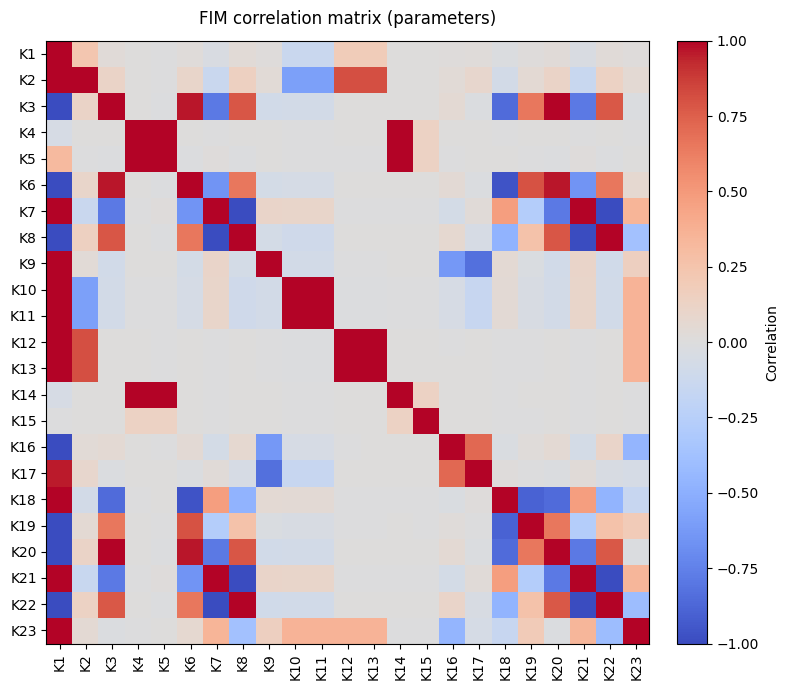

In [26]:

plt.figure(figsize=(8,7))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')
plt.title("FIM correlation matrix (parameters)", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES)
plt.tight_layout()

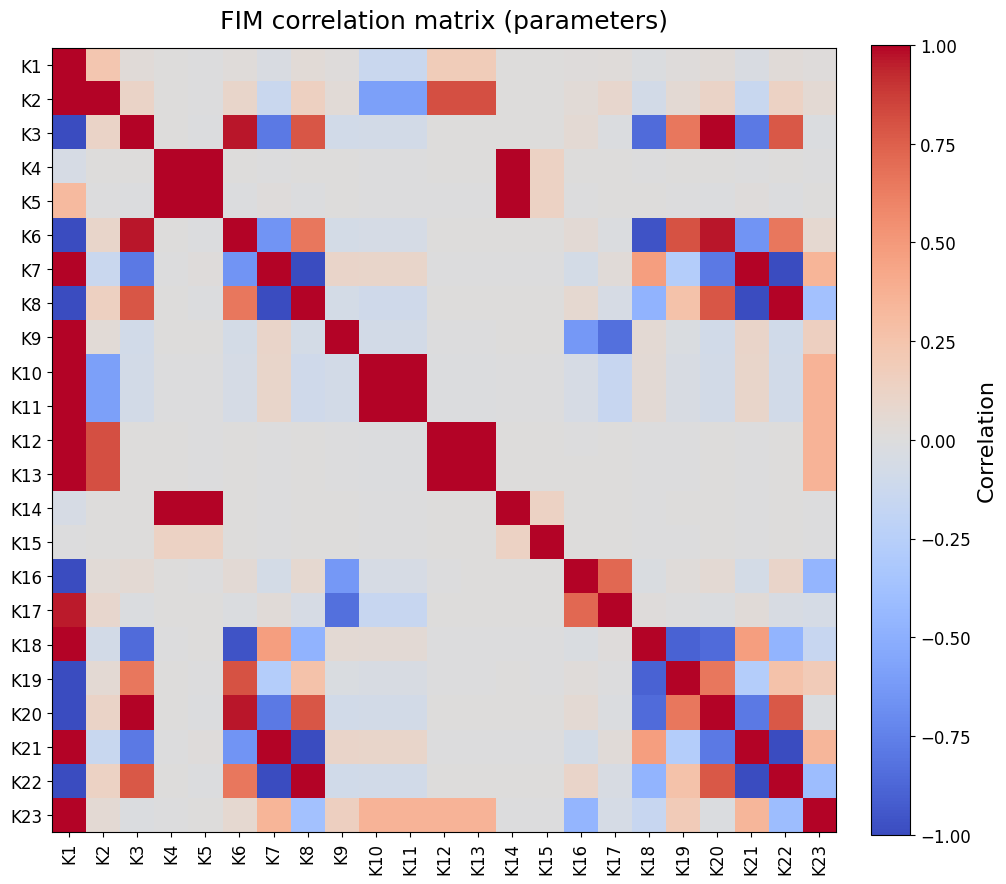

In [28]:
plt.figure(figsize=(10,9))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')

# Larger title font
plt.title("FIM correlation matrix (parameters)", fontsize=18, pad=14)

# Larger tick labels
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90, fontsize=12)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES, fontsize=12)

# Larger axis labels
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Correlation", fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


In [32]:
plt.figure(figsize=(10,9))
im = plt.imshow(R, vmin=-1, vmax=1, origin='upper', cmap='coolwarm')

# Larger title font
plt.title("FIM correlation matrix (parameters)", fontsize=18, pad=14)

# Larger tick labels
plt.xticks(range(len(PARAM_NAMES)), PARAM_NAMES, rotation=90, fontsize=12)
plt.yticks(range(len(PARAM_NAMES)), PARAM_NAMES, fontsize=12)

# Larger axis labels
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Correlation", fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("profiles/fim_corr_heatmap_bigfont.pdf", dpi=300, bbox_inches="tight")
plt.savefig("profiles/fim_corr_heatmap_bigfont.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved profiles/fim_corr_heatmap_bigfont.png at 300 dpi")


Saved profiles/fim_corr_heatmap_bigfont.png at 300 dpi
